In [10]:
from bloom import *
from lab1.hyperloglog import HyperLogLog
from lab1.quotient import QuotientFilter
from lab1.count_min_sketch import CountMinSketch
from lab1.minhash import MinHash


In [11]:
from prettytable import PrettyTable
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import random

In [12]:
gen_template = lambda x: f'192.168.56.{x}'

## Фильтр Блума

### Определить процент ложноположительных срабатываний конкретной реализации

In [13]:
ips_to_add = [gen_template(i) for i in range(20000)]
ips_to_find = [gen_template(i) for i in range(20000, 40000)]
ips_to_delete = [gen_template(i) for i in range(1000, 10000)]

def fill_filter(target):
    target.clear()
    for ip in ips_to_add:
        target.add(ip)

def delete_from_filter(target):
    for ip in ips_to_delete:
        target.remove(ip)
    
def get_pos_lie_perc(target, mode = 'add'):
    if mode == 'add':
        fill_filter(target)
    if mode == 'delete':
        delete_from_filter(target)
        
    return sum([target.contains(ip) for ip in ips_to_find])/len(ips_to_find) if mode == 'add' else sum([target.contains(ip) for ip in ips_to_delete])/len(ips_to_delete)
    

In [14]:
print(get_pos_lie_perc(BloomFilter(10000)))

1.0


### Оценить зависимость ложноположительных срабатываний относительно размерности массива m и числа хеш-функций k (таблица и графики зависимостей).

In [15]:
def make_report():
    data = {}
    for m in range(2000, 20000, 2000):
        data[m] = {}
        for hfc in range(1, 10):
            bf = BloomFilter(m, hfc=hfc)
            data[m][hfc] = round(get_pos_lie_perc(bf), 3)
        
    table = PrettyTable()      
    hash_func_counts = sorted({hash_func_count for m in data for hash_func_count in data[m]})
    
    table.field_names = ["m"] + hash_func_counts
    
    for m, hash_data in data.items():
        row = [m] 
        for hash_func_count in hash_func_counts:
            value = hash_data.get(hash_func_count, 0)  
            row.append(value)
        table.add_row(row)
    
    plt.figure(figsize=(10, 6)) 
    for hash_func_count in hash_func_counts:
        m_values = sorted(data.keys())  
        value_for_hash = [data[m].get(hash_func_count, 0) for m in m_values]  
        
        plt.plot(m_values, value_for_hash, marker='o', label=f"hash_func_count = {hash_func_count}")
    
    plt.title("Зависимость значения от m при фиксированных hash_func_count")
    plt.xlabel("Размер битового массива (m)")
    plt.ylabel("Процент ложноположительных срабатываний")
    plt.legend(title="Количество хеш-функций")
    plt.grid(True)
    plt.xticks(rotation=45)  
    plt.tight_layout()
    plt.show()
    
    return data, table

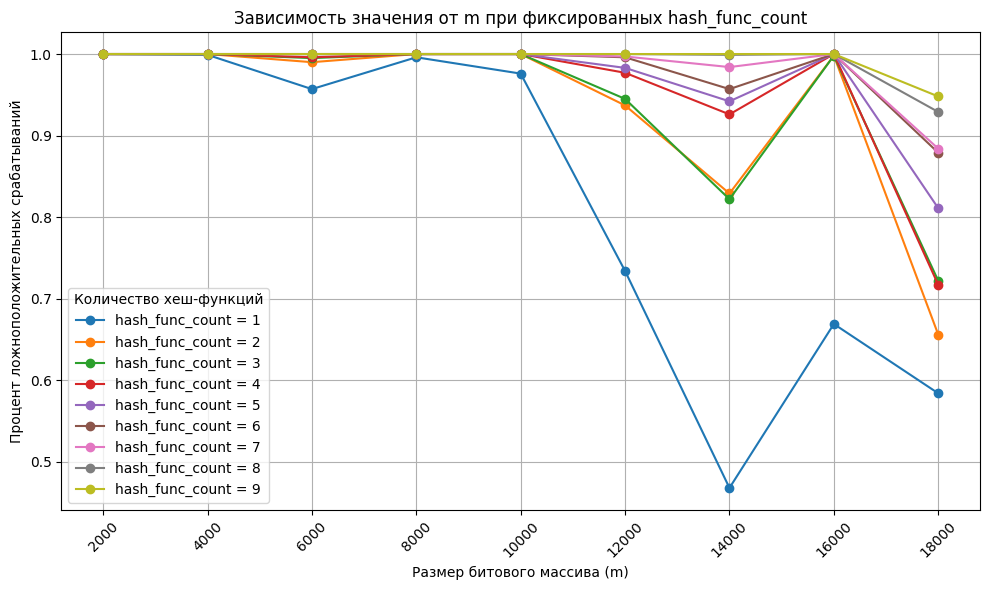

In [16]:

data, table = make_report()

In [17]:
print(table)

+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|   m   |   1   |   2   |   3   |   4   |   5   |   6   |   7   |   8   |   9   |
+-------+-------+-------+-------+-------+-------+-------+-------+-------+-------+
|  2000 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
|  4000 | 0.999 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
|  6000 | 0.957 |  0.99 | 0.995 | 0.996 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
|  8000 | 0.996 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
| 10000 | 0.976 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
| 12000 | 0.734 | 0.937 | 0.945 | 0.977 | 0.983 | 0.996 | 0.997 |  1.0  |  1.0  |
| 14000 | 0.468 | 0.829 | 0.822 | 0.926 | 0.942 | 0.957 | 0.984 | 0.999 |  1.0  |
| 16000 | 0.669 | 0.998 | 0.998 |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |  1.0  |
| 18000 | 0.584 | 0.656 | 0.722 | 0.717 | 0.811 | 0.879 | 0.884 | 0.929 | 0.948 |
+-------+-------

###  Произвести многофакторный дисперсионный анализ для выявления степени значимости следующих факторов: размерности массива m и числа хеш-функций k

In [18]:
def analysis(data):
    df = []
    for m, hash_data in data.items():
        for hash_func_count, value in hash_data.items():
            df.append({'m': m, 'hash_func_count': hash_func_count, 'value': value})

    df = pd.DataFrame(df)
    model = ols('value ~ C(m) + C(hash_func_count)', data=df).fit()
    anova_result = anova_lm(model)
    
    print(anova_result)

In [19]:
analysis(data)

                      df    sum_sq   mean_sq         F        PR(>F)
C(m)                 8.0  0.371801  0.046475  9.752500  9.789844e-09
C(hash_func_count)   8.0  0.210906  0.026363  5.532168  2.533403e-05
Residual            64.0  0.304989  0.004765       NaN           NaN


## Фильтр Блума со счетчиком

In [20]:
print(get_pos_lie_perc(CounterBF(10000), mode = 'delete'))

1.0


In [21]:
def make_report():
    data = {}
    for m in range(2000, 20000, 2000):
        data[m] = {}
        for hfc in range(1, 10):
            bf = CounterBF(m, hfc=hfc)
            data[m][hfc] = round(get_pos_lie_perc(bf, mode='delete'), 3)
        
    table = PrettyTable()      
    hash_func_counts = sorted({hash_func_count for m in data for hash_func_count in data[m]})
    
    table.field_names = ["m"] + hash_func_counts
    
    for m, hash_data in data.items():
        row = [m] 
        for hash_func_count in hash_func_counts:
            value = hash_data.get(hash_func_count, 0)  
            row.append(value)
        table.add_row(row)
    
    plt.figure(figsize=(10, 6)) 
    for hash_func_count in hash_func_counts:
        m_values = sorted(data.keys())  
        value_for_hash = [data[m].get(hash_func_count, 0) for m in m_values]  
        
        plt.plot(m_values, value_for_hash, marker='o', label=f"hash_func_count = {hash_func_count}")
    
    plt.title("Зависимость значения от m при фиксированных hash_func_count")
    plt.xlabel("Размер битового массива (m)")
    plt.ylabel("Процент ложноположительных срабатываний")
    plt.legend(title="Количество хеш-функций")
    plt.grid(True)
    plt.xticks(rotation=45)  
    plt.tight_layout()
    plt.show()
    
    return data, table

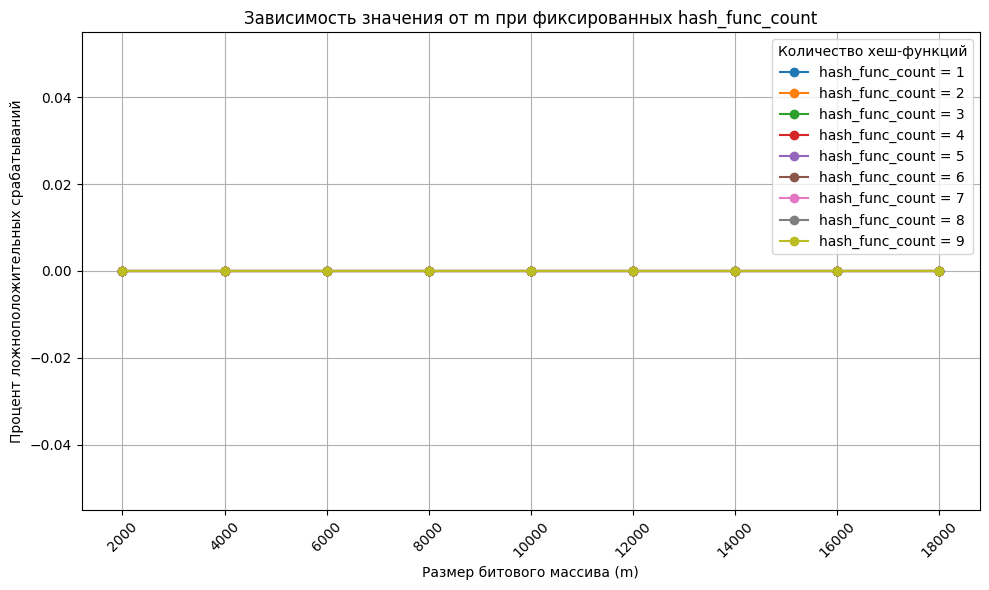

In [22]:
data, table = make_report()

In [23]:
print(table)

+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|   m   |  1  |  2  |  3  |  4  |  5  |  6  |  7  |  8  |  9  |
+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+
|  2000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
|  4000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
|  6000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
|  8000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 10000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 12000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 14000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 16000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 18000 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
+-------+-----+-----+-----+-----+-----+-----+-----+-----+-----+


## HyperLogLog

In [24]:
hll = HyperLogLog(b=15)
ips_to_add = [gen_template(random.randint(0, 199)) for _ in range(1000)]
for ip in ips_to_add:
    hll.add(ip)

estimated_count = hll.estimate()
print(f"Оценка уникальных IP-адресов: {estimated_count}")

actual_count = len(set(ips_to_add))  
print(f"Истинное количество уникальных IP-адресов: {actual_count}")
print(f"Ложноположительная ошибка: {abs(estimated_count - actual_count) / actual_count}")

Оценка уникальных IP-адресов: 200.6128465138427
Истинное количество уникальных IP-адресов: 200
Ложноположительная ошибка: 0.0030642325692134876


In [25]:
results = []
for b in range(16, 25, 1):
    hll = HyperLogLog(b=b)

    for ip in ips_to_add:
        hll.add(ip)

    estimated_count = hll.estimate()

    false_positive_rate = abs(estimated_count - actual_count) / actual_count

    results.append({'b': b, 'estimated_count': estimated_count, 
                        'actual_count': actual_count, 'false_positive_rate': false_positive_rate})

+----+--------------------+--------------+---------------------+
| b  |  Estimated Count   | Actual Count | False Positive Rate |
+----+--------------------+--------------+---------------------+
| 16 | 200.30579808753393 |     200      |        0.0015       |
| 17 | 200.1527432888961  |     200      |        0.0008       |
| 18 | 200.07633277263525 |     200      |        0.0004       |
| 19 | 200.03815667666248 |     200      |        0.0002       |
| 20 | 200.01907591200327 |     200      |        0.0001       |
| 21 | 200.00953734971299 |     200      |        0.0000       |
| 22 | 200.0047685228863  |     200      |        0.0000       |
| 23 | 200.00238422361912 |     200      |        0.0000       |
| 24 | 200.00119210374976 |     200      |        0.0000       |
+----+--------------------+--------------+---------------------+


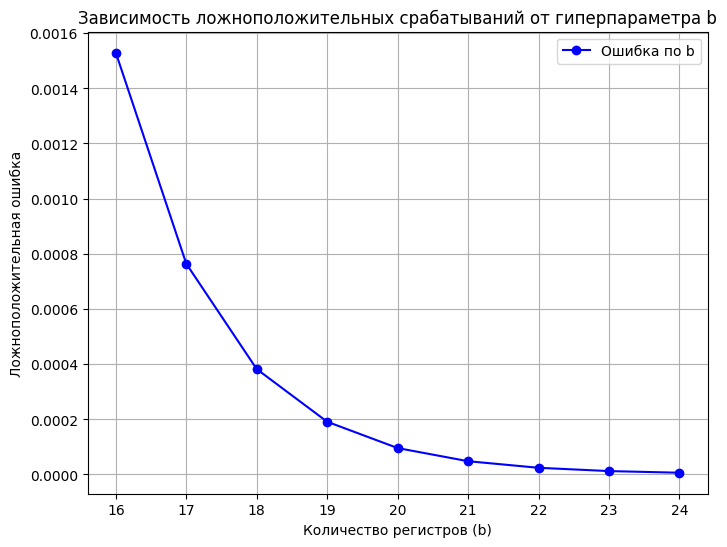

In [26]:
table = PrettyTable()

table.field_names = ["b", "Estimated Count", "Actual Count", "False Positive Rate"]

for result in results:
    table.add_row([result['b'], result['estimated_count'], result['actual_count'], f"{result['false_positive_rate']:.4f}"])

print(table)

plt.figure(figsize=(8, 6))

plt.plot([result['b'] for result in results], [result['false_positive_rate'] for result in results], marker='o', color='b', label='Ошибка по b')
plt.title('Зависимость ложноположительных срабатываний от гиперпараметра b')
plt.xlabel('Количество регистров (b)')
plt.ylabel('Ложноположительная ошибка')
plt.grid(True)
plt.legend()
plt.show()

## QuotientFilter

In [27]:
ips_to_add = [gen_template(i) for i in range(20000)]
ips_to_find = [gen_template(i) for i in range(20000, 40000)]

In [28]:
qf = QuotientFilter()

In [29]:
for ip in ips_to_add:
    qf.add(ip)

In [30]:
print(sum([qf.contains(ip) for ip in ips_to_find])/len(ips_to_add))

0.0825


In [31]:
def get_lie_perc(qf):
    for ip in ips_to_add:
        qf.add(ip)
    return round(sum([qf.contains(ip) for ip in ips_to_find])/len(ips_to_add), 3)

In [32]:
def make_report():
    data = {}
    for size in range(1000, 11000, 1000):
        data[size] = {}
        for q in range(2, 10, 2):
            qf = QuotientFilter(size=size, q_bits=q)
            data[size][q] = get_lie_perc(qf)
        
    table = PrettyTable()      
    qs = sorted({q for size in data for q in data[size]})
    
    table.field_names = ["size"] + qs
    
    for size, qs in data.items():
        row = [size] 
        for q in qs:
            value = qs.get(q, 0)  
            row.append(value)
        table.add_row(row)
    
    plt.figure(figsize=(10, 6)) 
    for q in qs:
        size_values = sorted(data.keys())  
        value = [data[size].get(q, 0) for size in size_values]  
        
        plt.plot(size_values, value, marker='o', label=f"q = {q}")
    
    plt.title("Зависимость значения от size при фиксированных q")
    plt.xlabel("Размер массива (size)")
    plt.ylabel("Процент ложноположительных срабатываний")
    plt.legend(title="Количество бит на частное")
    plt.grid(True)
    plt.xticks(rotation=45)  
    plt.tight_layout()
    plt.show()
    
    return data, table

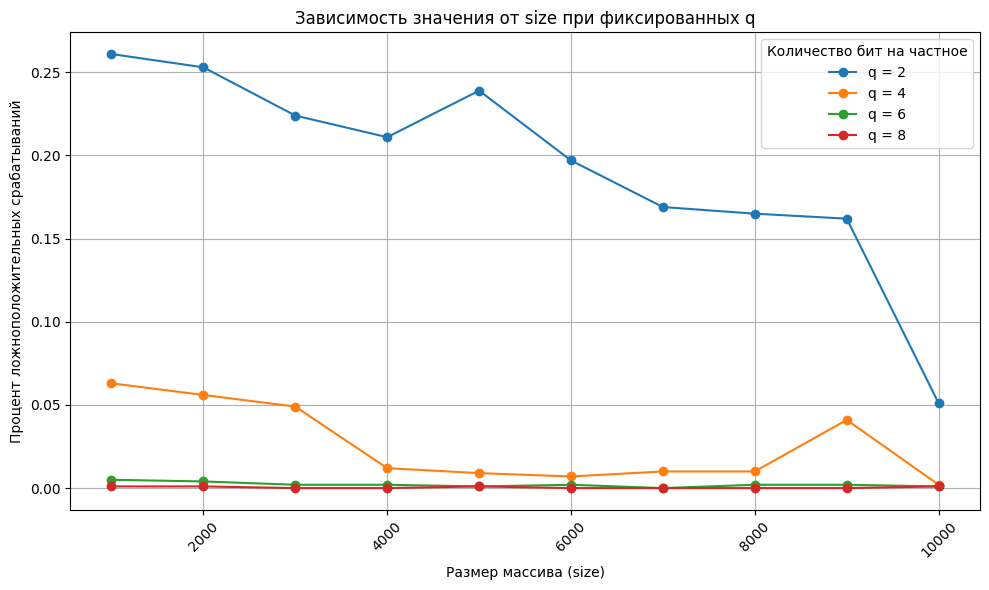

In [33]:
data, table = make_report()

In [34]:
print(table)

+-------+-------+-------+-------+-------+
|  size |   2   |   4   |   6   |   8   |
+-------+-------+-------+-------+-------+
|  1000 | 0.261 | 0.063 | 0.005 | 0.001 |
|  2000 | 0.253 | 0.056 | 0.004 | 0.001 |
|  3000 | 0.224 | 0.049 | 0.002 |  0.0  |
|  4000 | 0.211 | 0.012 | 0.002 |  0.0  |
|  5000 | 0.239 | 0.009 | 0.001 | 0.001 |
|  6000 | 0.197 | 0.007 | 0.002 |  0.0  |
|  7000 | 0.169 |  0.01 |  0.0  |  0.0  |
|  8000 | 0.165 |  0.01 | 0.002 |  0.0  |
|  9000 | 0.162 | 0.041 | 0.002 |  0.0  |
| 10000 | 0.051 | 0.002 | 0.001 | 0.001 |
+-------+-------+-------+-------+-------+


### CountMinSketch

In [35]:
cms = CountMinSketch(100, 2)

In [36]:
unique_ips = [gen_template(i) for i in range(2000)]
ips_to_find = [gen_template(i) for i in range(2000, 10000)]
items = []
real_counts = np.array([0]*len(unique_ips))
for _ in range(100000):
    idx = random.randint(0, len(unique_ips) - 1)
    cms.add(unique_ips[idx])
    items.append(unique_ips[idx])
    real_counts[idx] += 1

cms_counts = np.array([cms.count(item) for item in ips_to_find])
print(sum(cms_counts)/len(ips_to_find))
    

926.631875


In [37]:
def make_report():
    data = {}
    for size in range(10, 100, 10):
        data[size] = {}
        for hfc in range(1, 5):
            cms = CountMinSketch(size, hfc)
            for item in items:
                cms.add(item)
            cms_counts = np.array([cms.count(item) for item in ips_to_find])
            data[size][hfc] = sum(cms_counts)/len(ips_to_find)
        
    table = PrettyTable()      
    hfcs = sorted({hfc for size in data for hfc in data[size]})
    
    table.field_names = ["size"] + hfcs
    
    for size, hfcs in data.items():
        row = [size] 
        for hfc in hfcs:
            value = hfcs.get(hfc, 0)  
            row.append(value)
        table.add_row(row)
    
    plt.figure(figsize=(10, 6)) 
    for hfc in hfcs:
        size_values = sorted(data.keys())  
        value = [data[size].get(hfc, 0) for size in size_values]  
        
        plt.plot(size_values, value, marker='o', label=f"hfc = {hfc}")
    
    plt.title("Зависимость значения от size при фиксированных hfc")
    plt.xlabel("Размер массива (size)")
    plt.ylabel("Ложноположительные срабатывания")
    plt.legend(title="Количество хэш-функций")
    plt.grid(True)
    plt.xticks(rotation=45)  
    plt.tight_layout()
    plt.show()
    
    return data, table

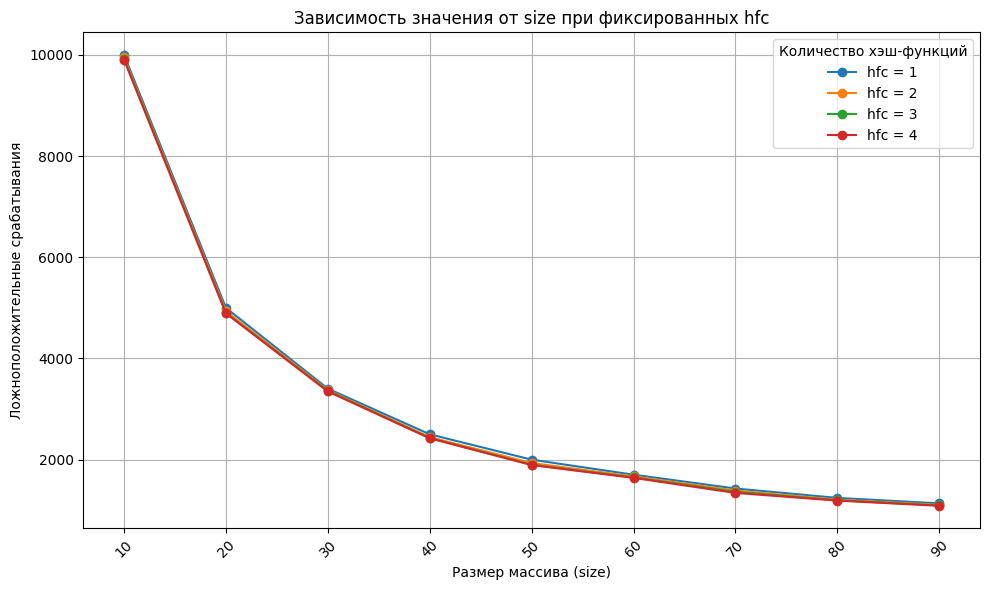

In [38]:
data, table = make_report()

## MinHash

In [39]:
def generate_sets(size: int, overlap_ratio: float, template: str = "item_{}"):
    overlap_size = int(size * overlap_ratio)
    unique_size = size - overlap_size
    
    common_elements = {f"{template.format(i)}" for i in range(overlap_size)}
    set1_unique = {f"{template.format(i)}" for i in range(overlap_size, overlap_size + unique_size)}
    set2_unique = {f"{template.format(i)}" for i in range(overlap_size + unique_size, overlap_size + 2 * unique_size)}
    
    set1 = common_elements | set1_unique
    set2 = common_elements | set2_unique
    
    return set1, set2

In [40]:
sizes = [50, 100, 200, 500] 
num_hashes_values = [10, 50, 100, 200] 
overlap = 0.5

table = PrettyTable(["Размер множеств", "num_hashes", "Истинное Jaccard", "MinHash Jaccard", "Относительная ошибка"])

errors = {}
for size in sizes:
    set1, set2 = generate_sets(size, overlap)
    errors[size] = []
    for num_hashes in num_hashes_values:
        minhasher = MinHash(num_hashes)
        signatures = minhasher.compute_signatures([set1, set2])
        minhash_jacc = minhasher.jaccard_similarity(signatures[:, 0], signatures[:, 1])
        
        relative_error = abs(minhash_jacc - 0.5) / 0.5
        errors[size].append(relative_error)
        table.add_row([size, num_hashes, 0.5, round(minhash_jacc, 4), round(relative_error, 4)])

print(table)

+-----------------+------------+------------------+-----------------+----------------------+
| Размер множеств | num_hashes | Истинное Jaccard | MinHash Jaccard | Относительная ошибка |
+-----------------+------------+------------------+-----------------+----------------------+
|        50       |     10     |       0.5        |       0.3       |         0.4          |
|        50       |     50     |       0.5        |       0.3       |         0.4          |
|        50       |    100     |       0.5        |       0.43      |         0.14         |
|        50       |    200     |       0.5        |       0.29      |         0.42         |
|       100       |     10     |       0.5        |       0.1       |         0.8          |
|       100       |     50     |       0.5        |       0.26      |         0.48         |
|       100       |    100     |       0.5        |       0.41      |         0.18         |
|       100       |    200     |       0.5        |      0.345      | 

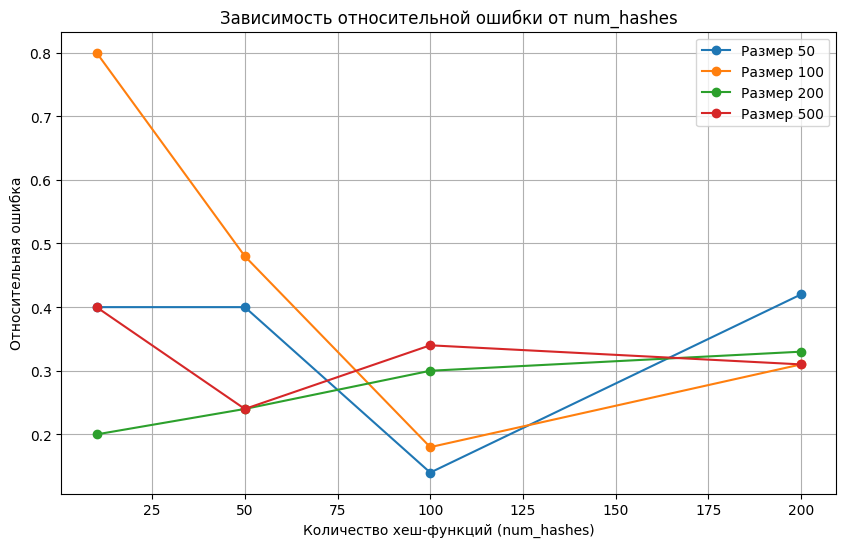

In [41]:
plt.figure(figsize=(10, 6))
for size in sizes:
    plt.plot(num_hashes_values, errors[size], marker='o', label=f'Размер {size}')

plt.xlabel("Количество хеш-функций (num_hashes)")
plt.ylabel("Относительная ошибка")
plt.title("Зависимость относительной ошибки от num_hashes")
plt.legend()
plt.grid()
plt.show()